In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
import numpy as np
from sklearn.metrics import classification_report

In [3]:
train_dir = 'demoDataset/Train/'
test_dir = 'demoDataset/Test/'

train_datagen = ImageDataGenerator(preprocessing_function=tf.keras.applications.resnet50.preprocess_input, validation_split=0.2)
test_datagen = ImageDataGenerator(preprocessing_function=tf.keras.applications.resnet50.preprocess_input)

train_generator = train_datagen.flow_from_directory(train_dir, batch_size=32, class_mode='categorical', target_size=(224, 224), subset='training', shuffle=True, color_mode='rgb', seed=42)
valid_generator = train_datagen.flow_from_directory(train_dir, batch_size=32, class_mode='categorical', target_size=(224, 224), subset='validation', shuffle=True, color_mode='rgb', seed=42)
test_generator = test_datagen.flow_from_directory(test_dir, batch_size=32, class_mode='categorical', target_size=(224, 224), shuffle=False, color_mode='rgb')

Found 2817 images belonging to 3 classes.
Found 703 images belonging to 3 classes.
Found 279 images belonging to 3 classes.


In [4]:
preTrained_model = ResNet50(include_top=False, weights='imagenet', input_shape=(224, 224, 3), pooling='avg')
preTrained_model.trainable = False

In [7]:
inputs = preTrained_model.input
x = tf.keras.layers.Dense(128, activation='relu')(preTrained_model.output)
x = tf.keras.layers.Dense(50, activation='relu')(x)
outputs = tf.keras.layers.Dense(3, activation='softmax')(x)
model = tf.keras.Model(inputs, outputs)
print(model.summary())

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_pad (ZeroPadding2D)     │ (None, 230, 230, 3)       │               0 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_conv (Conv2D)           │ (None, 112, 112, 64)      │           9,472 │ conv1_pad[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_bn (BatchNormalization) │ (None, 112, 112, 64)      │             256 │ conv1_conv[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_relu (Activation)       │ (None, 112, 112, 64)      │               0 │ conv1_bn[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1_pad (ZeroPadding2D)     │ (None, 114, 114, 64)      │               0 │ conv1_relu[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1_pool (MaxPooling2D)     │ (None, 56, 56, 64)        │               0 │ pool1_pad[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_conv (Conv2D)  │ (None, 56, 56, 64)        │           4,160 │ pool1_pool[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_bn             │ (None, 56, 56, 64)        │             256 │ conv2_block1_1_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_relu           │ (None, 56, 56, 64)        │               0 │ conv2_block1_1_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_conv (Conv2D)  │ (None, 56, 56, 64)        │          36,928 │ conv2_block1_1_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_bn             │ (None, 56, 56, 64)        │             256 │ conv2_block1_2_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_relu           │ (None, 56, 56, 64)        │               0 │ conv2_block1_2_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_0_conv (Conv2D)  │ (None, 56, 56, 256)       │          16,640 │ pool1_pool[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_3_conv (Conv2D)  │ (None, 56, 56, 256)       │          16,640 │ conv2_block1_2_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 23,856,587 (91.01 MB)

 Trainable params: 268,875 (1.03 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

None


In [8]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [9]:
callbacks = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
history = model.fit(train_generator, epochs=25, validation_data=valid_generator, callbacks=[callbacks])

Epoch 1/25


C:\Users\pc\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


89/89 ━━━━━━━━━━━━━━━━━━━━ 238s 3s/step - accuracy: 0.8894 - loss: 0.2345 - val_accuracy: 0.9886 - val_loss: 0.0280
Epoch 2/25
89/89 ━━━━━━━━━━━━━━━━━━━━ 987s 11s/step - accuracy: 0.9939 - loss: 0.0169 - val_accuracy: 1.0000 - val_loss: 0.0059
Epoch 3/25
89/89 ━━━━━━━━━━━━━━━━━━━━ 223s 2s/step - accuracy: 0.9977 - loss: 0.0062 - val_accuracy: 0.9915 - val_loss: 0.0200
Epoch 4/25
89/89 ━━━━━━━━━━━━━━━━━━━━ 223s 3s/step - accuracy: 0.9990 - loss: 0.0053 - val_accuracy: 0.9972 - val_loss: 0.0085
Epoch 5/25
89/89 ━━━━━━━━━━━━━━━━━━━━ 220s 2s/step - accuracy: 1.0000 - loss: 0.0015 - val_accuracy: 1.0000 - val_loss: 0.0028
Epoch 6/25
89/89 ━━━━━━━━━━━━━━━━━━━━ 220s 2s/step - accuracy: 1.0000 - loss: 3.8435e-04 - val_accuracy: 1.0000 - val_loss: 0.0024
Epoch 7/25
89/89 ━━━━━━━━━━━━━━━━━━━━ 224s 3s/step - accuracy: 1.0000 - loss: 2.2685e-04 - val_accuracy: 1.0000 - val_loss: 0.0019
Epoch 8/25
89/89 ━━━━━━━━━━━━━━━━━━━━ 226s 3s/step - accuracy: 1.0000 - loss: 2.2093e-04 - val_accuracy: 1.0000 -

KeyboardInterrupt: 

In [11]:
model.evaluate(test_generator)

9/9 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.9939 - loss: 0.0056


[0.003743604989722371, 0.9964157938957214]

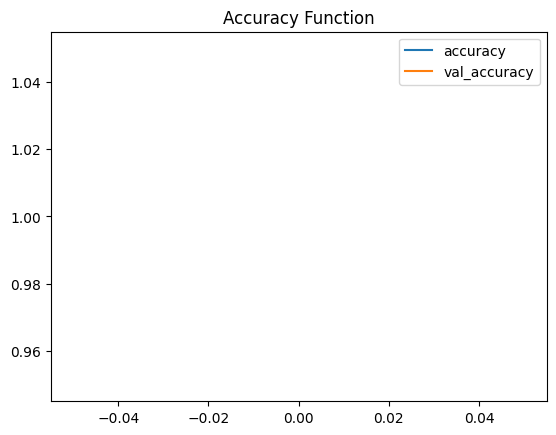

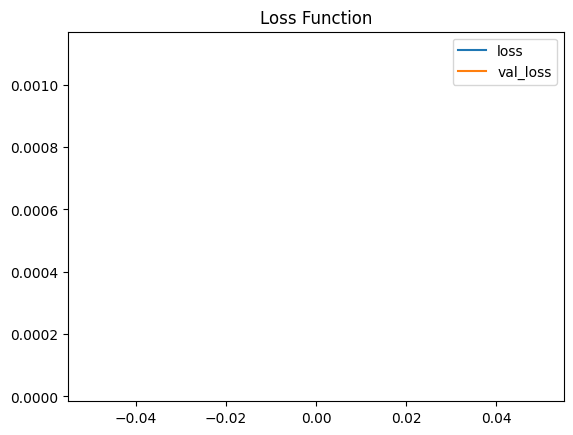

In [17]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('Accuracy Function')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss Function')
plt.legend()
plt.show()

In [12]:
y_pred = np.argmax(model.predict(test_generator), axis=1)
y_true = test_generator.classes
target_names = test_generator.class_indices.keys()
report = classification_report(y_pred, y_true, target_names=target_names, zero_division=0)

9/9 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step


In [13]:
print(report)

              precision    recall  f1-score   support

   Bar Chart       0.99      1.00      0.99        84
  Line Chart       1.00      0.99      0.99        97
   Pie Chart       1.00      1.00      1.00        98

    accuracy                           1.00       279
   macro avg       1.00      1.00      1.00       279
weighted avg       1.00      1.00      1.00       279



In [14]:
model.save('myModel.keras')
model.save_weights('myModel.weights.h5')